## Scenario Aziendale: Analisi dei Comportamenti d'Acquisto dei Clienti

### Contesto
Abbiamo una piattaforma e-commerce in rapida crescita specializzata nella vendita di abbigliamento e accessori di moda. Negli ultimi anni, l'azienda ha investito significativamente sia nel proprio sito web che nell'applicazione mobile per migliorare l'esperienza di acquisto dei clienti. Nonostante questi investimenti paralleli, le risorse aziendali per lo sviluppo tecnologico rimangono limitate e il team direttivo deve prendere decisioni strategiche su dove concentrare gli sforzi futuri.

### Situazione Attuale
Il Direttore Marketing ha raccolto dati dettagliati sul comportamento di 500 clienti, monitorando diverse metriche:
- Tempo trascorso sul sito web (in minuti)
- Tempo trascorso sull'app mobile (in minuti)
- Durata dell'iscrizione alla piattaforma (in anni)
- Spesa annuale (in euro)

Il team è particolarmente interessato a comprendere quali fattori influenzino maggiormente il valore economico generato dai clienti, con l'obiettivo di ottimizzare gli investimenti futuri.

### Obiettivi

1. Analizzare i dati per identificare le correlazioni tra le diverse variabili e la spesa annuale
2. Costruire un modello predittivo che possa stimare la spesa annuale dei clienti in base ai loro comportamenti
3. Determinare quale canale (sito web o app mobile) influenza maggiormente le decisioni di acquisto

### Domande Specifiche
- Esiste una correlazione significativa tra il tempo trascorso sul sito web e la spesa annuale?
- Esiste una correlazione significativa tra il tempo trascorso sull'app mobile e la spesa annuale?
- Quale variabile ha la correlazione più forte con la spesa annuale?
- Sulla base dei coefficienti del modello, dove l'azienda dovrebbe concentrare i propri investimenti?

In [2]:
#Importiamo le librerie e leggiamo il dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("CustomerData.csv")
df.head()

,Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


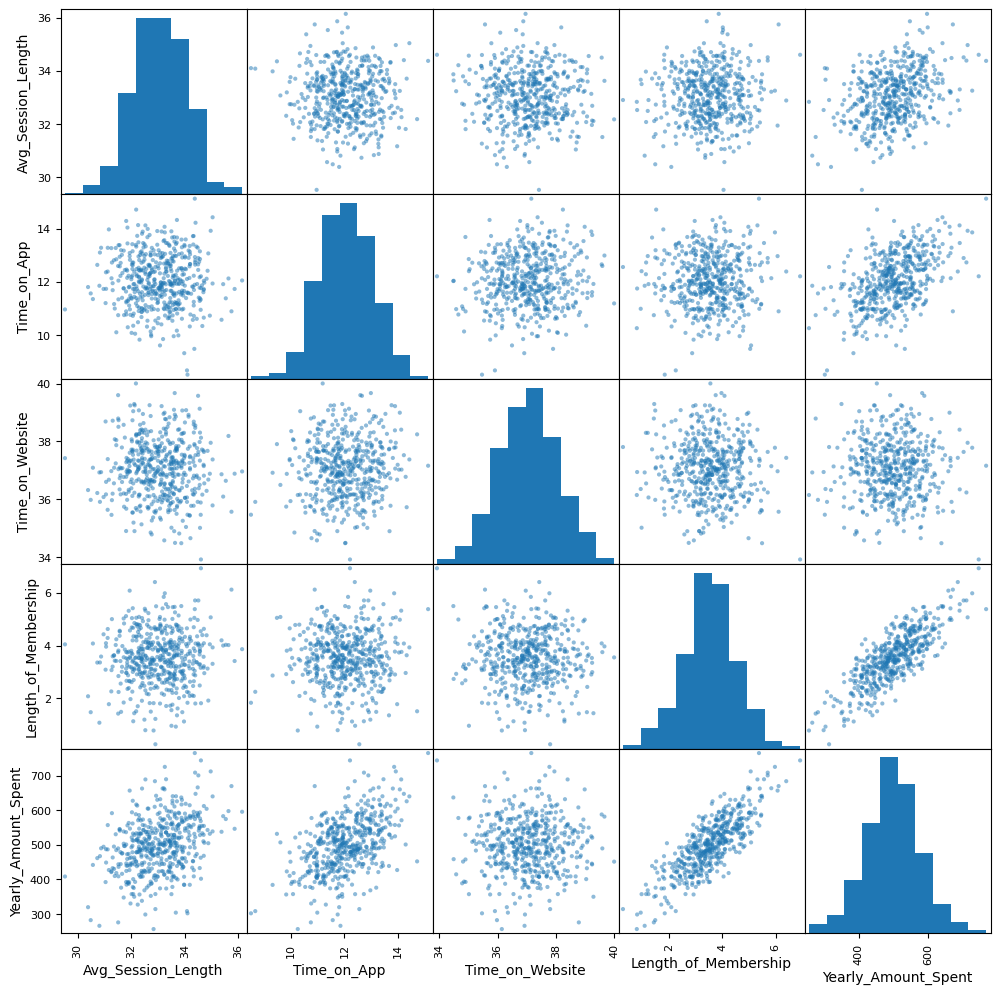

In [3]:
correlazioni = pd.plotting.scatter_matrix(df, figsize=(12, 12))

In [4]:
columns = ['Avg_Session_Length', 'Time_on_App',
       'Time_on_Website', 'Length_of_Membership', 'Yearly_Amount_Spent']


                      Avg_Session_Length  Time_on_App  Time_on_Website  \
Avg_Session_Length              1.000000    -0.027826        -0.034987   
Time_on_App                    -0.027826     1.000000         0.082388   
Time_on_Website                -0.034987     0.082388         1.000000   
Length_of_Membership            0.060247     0.029143        -0.047582   
Yearly_Amount_Spent             0.355088     0.499328        -0.002641   

                      Length_of_Membership  Yearly_Amount_Spent  
Avg_Session_Length                0.060247             0.355088  
Time_on_App                       0.029143             0.499328  
Time_on_Website                  -0.047582            -0.002641  
Length_of_Membership              1.000000             0.809084  
Yearly_Amount_Spent               0.809084             1.000000  


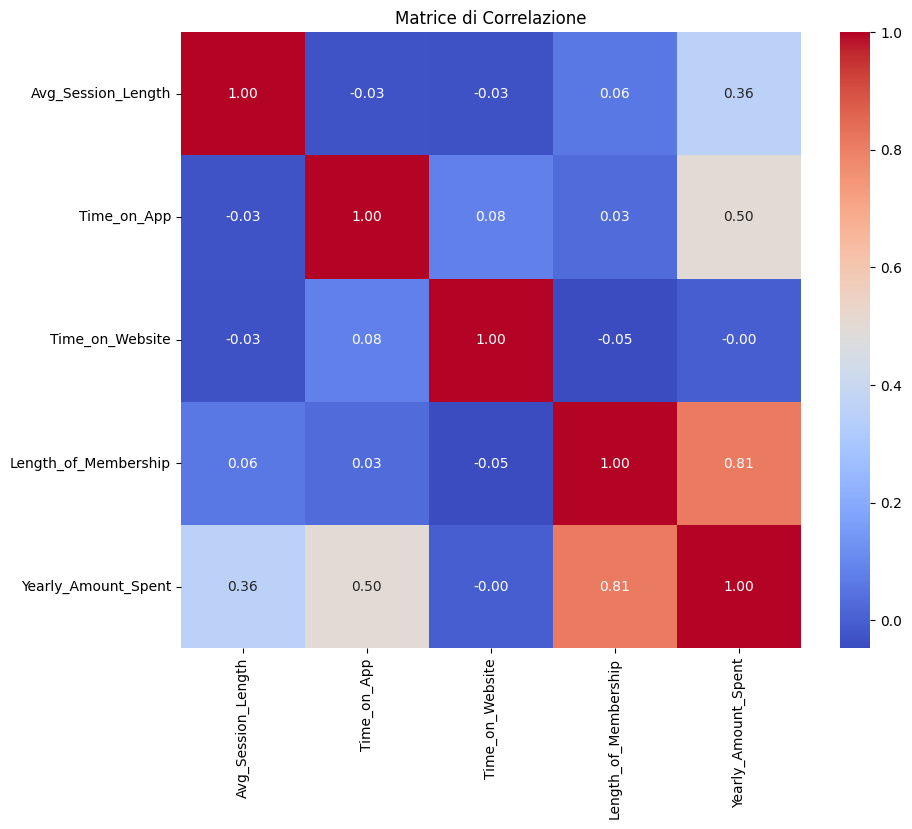

In [5]:
# Matrice di correlazione
corr_matrix = df[columns].corr()
print(corr_matrix)

# Visualizzazione tramite heatmap
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice di Correlazione')
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Time_on_App', 'Length_of_Membership']]
y = df['Yearly_Amount_Spent']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)

print("Pesi:", model.coef_)
print("W_0", model.intercept_)

Pesi: [38.66057465 62.53056614]
W_0 -187.0428145109372
